<a href="https://colab.research.google.com/github/maulidyaafriani/Pembelajaran-Mesin-2026/blob/main/Maulidya_Afriani_PembelajaranMesin_KUIS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**KUIS 1**

Nama: Maulidya Afriani
NIM: 244107020059
Kelas : TI-3G

**PERSIAPAN**

1. import library

In [82]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, pairwise_distances)
from google.colab import drive

drive.mount('/content/drive')
warnings.filterwarnings('ignore')

OUTPUT_DIR = "outputKmeans"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

path = '/content/drive/MyDrive/glucosafe/Datasate/diabetes_012_health_indicators_BRFSS2015.csv.zip'
df_raw = pd.read_csv(path)
print(df_raw.shape)   # (10000, 23)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(9577, 22)


In [83]:
print(df_raw.dtypes.value_counts())
print("Missing value:", df_raw.isnull().sum().sum())
print("Duplikat:", df_raw.duplicated().sum())
print(df_raw['Diabetes_012'].value_counts().sort_index())

float64    21
int64       1
Name: count, dtype: int64
Missing value: 0
Duplikat: 0
Diabetes_012
0.0    8217
2.0    1360
Name: count, dtype: int64


In [87]:

print(os.listdir('/content/drive/MyDrive/glucosafe'))

path = '/content/drive/MyDrive/glucosafe/Datasate/diabetes_012_health_indicators_BRFSS2015.csv.zip'
df = pd.read_csv(path)
print(df.shape)
df.head()

['Datasate']
(9577, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Cluster,Diabetes_012
0,-0.872425,-0.863917,0.19877,-1.459978,1.101040,-0.211484,-0.325994,-1.756631,-1.309416,-2.030796,...,-0.311281,-0.493475,-0.437389,-0.489159,-0.451214,-0.903647,-0.658485,-0.034631,0,0.0
1,1.146230,-0.863917,0.19877,2.529546,-0.908232,-0.211484,-0.325994,0.569272,0.763699,0.492418,...,-0.311281,1.378212,1.443622,1.777145,-0.451214,-0.903647,0.649878,-2.069356,-1,0.0
2,-0.872425,1.157518,0.19877,0.074454,-0.908232,-0.211484,-0.325994,0.569272,0.763699,0.492418,...,-0.311281,1.378212,-0.437389,-0.489159,-0.451214,1.106627,0.322787,-0.034631,0,0.0
3,-0.872425,-0.863917,0.19877,-0.078989,-0.908232,-0.211484,-0.325994,0.569272,0.763699,0.492418,...,-0.311281,-0.493475,-0.437389,0.304047,-0.451214,-0.903647,0.322787,0.982732,0,0.0
4,-0.872425,-0.863917,0.19877,-0.846205,1.101040,-0.211484,-0.325994,0.569272,0.763699,0.492418,...,-0.311281,-1.429318,-0.437389,-0.489159,-0.451214,-0.903647,0.322787,0.982732,0,0.0


In [ ]:
# Cek data awal
print("Tipe data tiap kolom:")
print(df_raw.dtypes.value_counts())

print("\nTotal missing value per kolom (hanya yang > 0):")
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing value")

print(f"\nJumlah baris duplikat: {df_raw.duplicated().sum()}")

print("\nSebaran kelas Diabetes_012 (0=tidak, 1=pra-diabetes, 2=diabetes):")
print(df_raw['Diabetes_012'].value_counts().sort_index())

In [93]:
from google.colab import files
import shutil

up = files.upload()
nama_zip = list(up.keys())[0]

df_asli = pd.read_csv(nama_zip)
print(df_asli.shape)   # harus (10000, 23)
assert 'Income' in df_asli.columns, "Ini bukan file asli"

shutil.copy(nama_zip, '/content/drive/MyDrive/glucosafe/Datasate/diabetes_012_health_indicators_BRFSS2015.csv.zip')

Saving diabetes_012_health_indicators_BRFSS2015.csv (3).zip to diabetes_012_health_indicators_BRFSS2015.csv (3) (1).zip
(10000, 23)


'/content/drive/MyDrive/glucosafe/Datasate/diabetes_012_health_indicators_BRFSS2015.csv.zip'

In [95]:
path = '/content/drive/MyDrive/glucosafe/Datasate/diabetes_012_health_indicators_BRFSS2015.csv.zip'
df_asli = pd.read_csv(path)
print("Data dibaca:", df_asli.shape)

df = df_asli.copy()
n_awal = len(df)

# 1. Buang kelas 1 (kalau sudah tidak ada, otomatis terbuang 0)
df = df[df['Diabetes_012'] != 1]
print(f"Setelah buang kelas 1  : {len(df)} baris (terbuang {n_awal - len(df)})")

# 2. Buang Income dan Cluster (kolom yang sudah tidak ada dilewati)
df = df.drop(columns=['Income', 'Cluster'], errors='ignore')
print(f"Setelah buang kolom    : {df.shape[1]} kolom")

# 3. Buang duplikat
n_sebelum = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Setelah hapus duplikat : {len(df)} baris (terbuang {n_sebelum - len(df)})")

# 4. Fitur dan label
y_label = df['Diabetes_012'].copy()
df_features = df.drop(columns=['Diabetes_012']).astype(float)

# 5. Standardisasi
X_scaled = StandardScaler().fit_transform(df_features.values)

print("Jumlah fitur:", df_features.shape[1])
print("Bentuk data :", X_scaled.shape)
print("Daftar fitur:", list(df_features.columns))

Data dibaca: (10000, 23)
Setelah buang kelas 1  : 9820 baris (terbuang 180)
Setelah buang kolom    : 21 kolom
Setelah hapus duplikat : 9577 baris (terbuang 243)
Jumlah fitur: 20
Bentuk data : (9577, 20)
Daftar fitur: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education']


**DBSCAN Cosine = maulidya afriani/244107020059**

In [34]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import time

X = df.values   # data hasil standarisasi
min_samples_awal = 16   # 2 x jumlah fitur (8 fitur)

K-distance plot

[INFO] Ukuran data penuh: (9577, 22) | Ukuran sampel: (9577, 22)


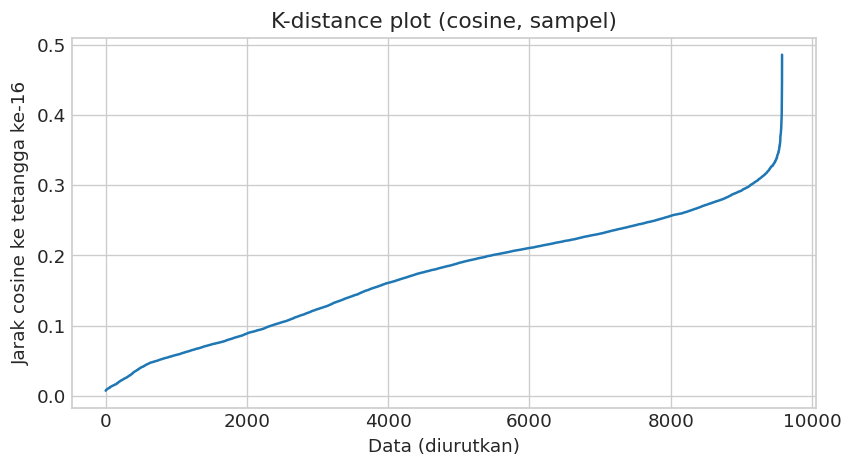

Persentil 50/70/80/90/95: [0.1838 0.2248 0.247  0.276  0.2976]


In [35]:
# K-distance plot (cosine) - memakai sampel agar tidak terlalu berat
from sklearn.neighbors import NearestNeighbors

N_SAMPLE = 15000
X_arr = np.asarray(X)                      # aman untuk DataFrame maupun array
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(X_arr.shape[0], min(N_SAMPLE, X_arr.shape[0]), replace=False)
X_sample = X_arr[idx]
print(f"[INFO] Ukuran data penuh: {X_arr.shape} | Ukuran sampel: {X_sample.shape}")

nn = NearestNeighbors(n_neighbors=min_samples_awal, metric='cosine', n_jobs=-1).fit(X_sample)
dist, _ = nn.kneighbors(X_sample)
k_dist = np.sort(dist[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_dist)
plt.xlabel('Data (diurutkan)')
plt.ylabel(f'Jarak cosine ke tetangga ke-{min_samples_awal}')
plt.title('K-distance plot (cosine, sampel)')
plt.show()

print('Persentil 50/70/80/90/95:', np.percentile(k_dist, [50, 70, 80, 90, 95]).round(4))

**Eksperimen eps dan min_samples**

In [36]:
# Eksperimen eps dan min_samples (DBSCAN cosine, memakai sampel)
persentil_list = [50, 70, 80, 90, 95]
ms_list = [8, 16, 32]

baris = []
for p in persentil_list:
    eps = float(np.percentile(k_dist, p))
    for ms in ms_list:
        mulai = time.time()
        lab = DBSCAN(eps=eps, min_samples=ms, metric='cosine', n_jobs=-1).fit_predict(X_sample)
        mask = lab != -1
        n_cl = len(set(lab[mask]))
        if n_cl >= 2:
            sil = silhouette_score(X_sample[mask], lab[mask], metric='cosine',
                                   sample_size=min(3000, int(mask.sum())), random_state=RANDOM_STATE)
        else:
            sil = np.nan
        baris.append({'eps': round(eps, 4), 'min_samples': ms, 'Klaster': n_cl,
                      'Noise': int((~mask).sum()), 'Noise (%)': round(100 * (~mask).mean(), 1),
                      'Silhouette': round(sil, 3)})
        print(f"[INFO] persentil={p}, eps={eps:.4f}, min_samples={ms} selesai ({time.time() - mulai:.1f} detik)")

grid_cosine = pd.DataFrame(baris)
grid_cosine

[INFO] persentil=50, eps=0.1838, min_samples=8 selesai (1.8 detik)
[INFO] persentil=50, eps=0.1838, min_samples=16 selesai (1.4 detik)
[INFO] persentil=50, eps=0.1838, min_samples=32 selesai (1.3 detik)
[INFO] persentil=70, eps=0.2248, min_samples=8 selesai (1.3 detik)
[INFO] persentil=70, eps=0.2248, min_samples=16 selesai (1.2 detik)
[INFO] persentil=70, eps=0.2248, min_samples=32 selesai (1.3 detik)
[INFO] persentil=80, eps=0.2470, min_samples=8 selesai (1.6 detik)
[INFO] persentil=80, eps=0.2470, min_samples=16 selesai (1.7 detik)
[INFO] persentil=80, eps=0.2470, min_samples=32 selesai (3.5 detik)
[INFO] persentil=90, eps=0.2760, min_samples=8 selesai (2.5 detik)
[INFO] persentil=90, eps=0.2760, min_samples=16 selesai (1.5 detik)
[INFO] persentil=90, eps=0.2760, min_samples=32 selesai (1.3 detik)
[INFO] persentil=95, eps=0.2976, min_samples=8 selesai (1.3 detik)
[INFO] persentil=95, eps=0.2976, min_samples=16 selesai (1.2 detik)
[INFO] persentil=95, eps=0.2976, min_samples=32 seles

,eps,min_samples,Klaster,Noise,Noise (%),Silhouette
0,0.1838,8,17,1006,10.5,-0.125
1,0.1838,16,17,2405,25.1,-0.061
2,0.1838,32,17,4459,46.6,0.027
3,0.2248,8,3,173,1.8,-0.050
4,0.2248,16,3,682,7.1,0.087
5,0.2248,32,9,2151,22.5,0.069
6,0.2470,8,2,47,0.5,0.041
7,0.2470,16,3,247,2.6,-0.020
8,0.2470,32,4,1014,10.6,0.074
9,0.2760,8,2,6,0.1,0.042


**Pilih parameter dan model final**

In [37]:
# Pilih otomatis: klaster >= 2, noise <= 30%, Silhouette tertinggi
kandidat = grid_cosine[(grid_cosine['Klaster'] >= 2) & (grid_cosine['Noise (%)'] <= 30)]
if len(kandidat) > 0:
    pilih = kandidat.sort_values('Silhouette', ascending=False).iloc[0]
    eps_final, ms_final = float(pilih['eps']), int(pilih['min_samples'])
else:
    eps_final, ms_final = float(np.percentile(k_dist, 90)), 16

# Atur manual bila perlu, contoh:
# eps_final, ms_final = 0.12, 16

start_time_dbscan = time.time()
db_cos = DBSCAN(eps=eps_final, min_samples=ms_final, metric='cosine', n_jobs=-1)
y_dbscan = db_cos.fit_predict(X_sample)
end_time_dbscan = time.time()

n_clusters_ = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
n_noise_ = list(y_dbscan).count(-1)

print(f'[INFO] Data yang dipakai: sampel {X_sample.shape[0]} baris')
print(f'eps = {eps_final}, min_samples = {ms_final}')
print('Jumlah klaster:', n_clusters_)
print('Jumlah noise  :', n_noise_)
print('Anggota per label (-1 = noise):', dict(zip(*np.unique(y_dbscan, return_counts=True))))
print(f'Waktu komputasi: {end_time_dbscan - start_time_dbscan:.1f} detik')

[INFO] Data yang dipakai: sampel 9577 baris
eps = 0.2248, min_samples = 16
Jumlah klaster: 3
Jumlah noise  : 682
Anggota per label (-1 = noise): {np.int64(-1): np.int64(682), np.int64(0): np.int64(8112), np.int64(1): np.int64(440), np.int64(2): np.int64(343)}
Waktu komputasi: 1.2 detik


**Visualisasi**

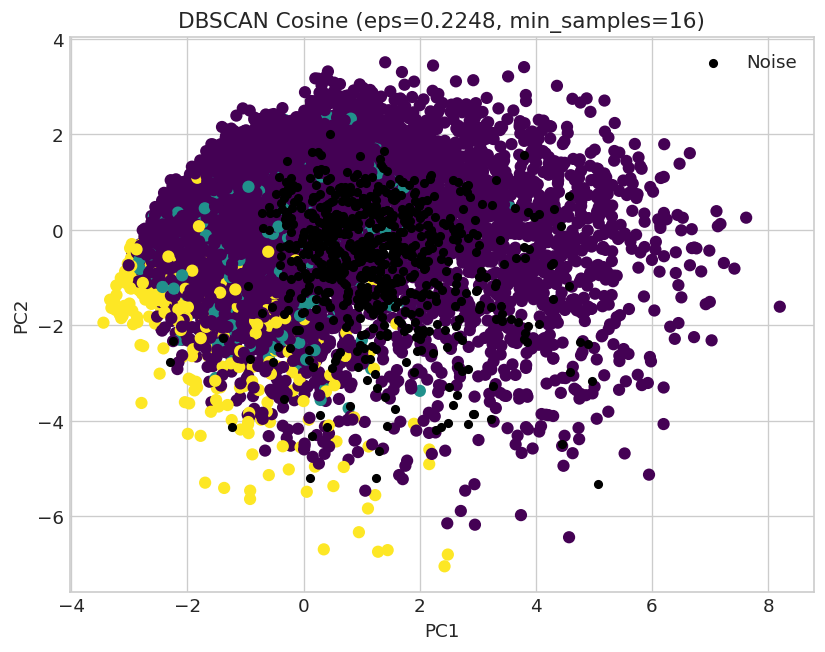

[INFO] Varians dijelaskan PC1+PC2: 24.7%


In [38]:
from sklearn.decomposition import PCA

# Reduksi ke 2 dimensi untuk visualisasi
pca = PCA(n_components=2, random_state=RANDOM_STATE)
komp = pca.fit_transform(X_sample)

noise = y_dbscan == -1

plt.figure(figsize=(8, 6))
plt.scatter(komp[~noise, 0], komp[~noise, 1],
            c=y_dbscan[~noise], s=40, cmap='viridis')
plt.scatter(komp[noise, 0], komp[noise, 1],
            c='black', s=20, label='Noise')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'DBSCAN Cosine (eps={eps_final}, min_samples={ms_final})')
plt.legend()
plt.show()

print(f'[INFO] Varians dijelaskan PC1+PC2: {pca.explained_variance_ratio_.sum() * 100:.1f}%')

**Evaluasi**

In [39]:
mask = y_dbscan != -1

if len(set(y_dbscan[mask])) >= 2:
    sil_cos = silhouette_score(X_sample[mask], y_dbscan[mask], metric='cosine')
    sil_euc = silhouette_score(X_sample[mask], y_dbscan[mask])
    dbi = davies_bouldin_score(X_sample[mask], y_dbscan[mask])
    chi = calinski_harabasz_score(X_sample[mask], y_dbscan[mask])
else:
    sil_cos = sil_euc = dbi = chi = np.nan

hasil_dbscan_cosine = pd.DataFrame({
    'Metode': ['DBSCAN Cosine'],
    'Jumlah Data': [X_sample.shape[0]],
    'eps': [eps_final],
    'min_samples': [ms_final],
    'Klaster': [n_clusters_],
    'Noise': [n_noise_],
    'Silhouette (cosine)': [sil_cos],
    'Silhouette (euclidean)': [sil_euc],
    'DBI': [dbi],
    'CHI': [chi],
    'Execution Time': [end_time_dbscan - start_time_dbscan],
})

print("=" * 80)
print("TABEL EVALUASI DBSCAN COSINE (tanpa titik noise)")
print("=" * 80)
print(hasil_dbscan_cosine.to_string(index=False))

TABEL EVALUASI DBSCAN COSINE (tanpa titik noise)
       Metode  Jumlah Data    eps  min_samples  Klaster  Noise  Silhouette (cosine)  Silhouette (euclidean)      DBI        CHI  Execution Time
DBSCAN Cosine         9577 0.2248           16        3    682             0.083831                0.183811 1.621988 494.242128        1.162441


**DBSCAN_Manhattan**

In [40]:
# Melihat informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9577 entries, 0 to 9576
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   HighBP                9577 non-null   float64
 1   HighChol              9577 non-null   float64
 2   CholCheck             9577 non-null   float64
 3   BMI                   9577 non-null   float64
 4   Smoker                9577 non-null   float64
 5   Stroke                9577 non-null   float64
 6   HeartDiseaseorAttack  9577 non-null   float64
 7   PhysActivity          9577 non-null   float64
 8   Fruits                9577 non-null   float64
 9   Veggies               9577 non-null   float64
 10  HvyAlcoholConsump     9577 non-null   float64
 11  AnyHealthcare         9577 non-null   float64
 12  NoDocbcCost           9577 non-null   float64
 13  GenHlth               9577 non-null   float64
 14  MentHlth              9577 non-null   float64
 15  PhysHlth             

In [41]:
# Memisahkan target dan fitur
target = df['Diabetes_012']

X = df.drop(columns=['Diabetes_012'])

X.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Cluster
0,-0.866785,-0.858182,0.196922,-1.117071,-0.892119,-0.205637,-0.322458,-1.762814,0.759375,0.482087,...,0.226863,-0.303173,0.457294,-0.024926,0.316350,-0.449718,-0.887021,-0.337933,-1.065595,0
1,1.153688,1.165254,0.196922,-0.057858,-0.892119,-0.205637,-0.322458,0.567275,0.759375,0.482087,...,0.226863,-0.303173,0.457294,-0.429630,-0.486592,-0.449718,-0.887021,1.626566,0.963272,0
2,-0.866785,-0.858182,0.196922,-0.663122,-0.892119,-0.205637,-0.322458,0.567275,0.759375,0.482087,...,0.226863,-0.303173,-1.414532,-0.429630,-0.486592,-0.449718,1.127369,-2.302431,-1.065595,0
3,-0.866785,-0.858182,0.196922,-0.209174,1.120927,-0.205637,-0.322458,0.567275,-1.316872,0.482087,...,0.226863,-0.303173,-0.478619,-0.024926,-0.486592,-0.449718,1.127369,-1.975015,-1.065595,0
4,-0.866785,1.165254,0.196922,0.396091,1.120927,-0.205637,-0.322458,-1.762814,0.759375,0.482087,...,0.226863,3.298445,1.393207,3.212703,2.610472,2.223615,-0.887021,-0.010516,-2.080028,-1


In [42]:
# Standardisasi Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.87242502, -0.86391726,  0.19876969, -1.15309119, -0.90823217,
        -0.21148439, -0.32599445, -1.75663054,  0.76369948,  0.49241786,
        -0.24944481,  0.22995736, -0.31128141,  0.44236848, -0.0343155 ,
         0.30404727, -0.45121427, -0.90364714, -0.33139425, -1.05199344,
         0.40597527],
       [ 1.14623031,  1.15751826,  0.19876969, -0.07898873, -0.90823217,
        -0.21148439, -0.32599445,  0.56927167,  0.76369948,  0.49241786,
        -0.24944481,  0.22995736, -0.31128141,  0.44236848, -0.43738932,
        -0.48915914, -0.45121427, -0.90364714,  1.63115101,  0.98273163,
         0.40597527],
       [-0.87242502, -0.86391726,  0.19876969, -0.69276156, -0.90823217,
        -0.21148439, -0.32599445,  0.56927167,  0.76369948,  0.49241786,
        -0.24944481,  0.22995736, -0.31128141, -1.42931827, -0.43738932,
        -0.48915914, -0.45121427,  1.10662665, -2.29393952, -1.05199344,
         0.40597527],
       [-0.87242502, -0.86391726,  0.19876969, -0.23243194

In [44]:
# Mengambil sampel data
sample_size = 10000

np.random.seed(42)

n = X_scaled.shape[0]
sample_size = min(sample_size, n)

sample_idx = np.random.choice(n, size=sample_size, replace=False)

X_sample = X_scaled[sample_idx]

target_sample = target.iloc[sample_idx].reset_index(drop=True)

X_sample.shape

(9577, 21)

In [45]:
# DBSCAN Manhattan
dbscan = DBSCAN(
    eps=5,
    min_samples=10,
    metric='manhattan',
    n_jobs=-1
)

labels = dbscan.fit_predict(X_sample)

labels


array([ 0, -1,  0, ...,  0,  0, -1])

In [46]:
# Menambahkan hasil cluster
df_cluster = pd.DataFrame(
    X_sample,
    columns=X.columns
)

df_cluster['Cluster'] = labels
df_cluster['Diabetes_012'] = target_sample

df_cluster.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Cluster,Diabetes_012
0,-0.872425,-0.863917,0.19877,-1.459978,1.101040,-0.211484,-0.325994,-1.756631,-1.309416,-2.030796,...,-0.311281,-0.493475,-0.437389,-0.489159,-0.451214,-0.903647,-0.658485,-0.034631,0,0.0
1,1.146230,-0.863917,0.19877,2.529546,-0.908232,-0.211484,-0.325994,0.569272,0.763699,0.492418,...,-0.311281,1.378212,1.443622,1.777145,-0.451214,-0.903647,0.649878,-2.069356,-1,0.0
2,-0.872425,1.157518,0.19877,0.074454,-0.908232,-0.211484,-0.325994,0.569272,0.763699,0.492418,...,-0.311281,1.378212,-0.437389,-0.489159,-0.451214,1.106627,0.322787,-0.034631,0,0.0
3,-0.872425,-0.863917,0.19877,-0.078989,-0.908232,-0.211484,-0.325994,0.569272,0.763699,0.492418,...,-0.311281,-0.493475,-0.437389,0.304047,-0.451214,-0.903647,0.322787,0.982732,0,0.0
4,-0.872425,-0.863917,0.19877,-0.846205,1.101040,-0.211484,-0.325994,0.569272,0.763699,0.492418,...,-0.311281,-1.429318,-0.437389,-0.489159,-0.451214,-0.903647,0.322787,0.982732,0,0.0


In [47]:
# Jumlah data setiap cluster
cluster_counts = df_cluster['Cluster'].value_counts().sort_index()

print(cluster_counts)

# Jumlah cluster tanpa noise
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Jumlah noise
n_noise = list(labels).count(-1)

print("Jumlah Cluster :", n_clusters)
print("Jumlah Noise   :", n_noise)

# Data tanpa noise
mask = labels != -1

X_eval = X_sample[mask]
labels_eval = labels[mask]

# Evaluasi Silhouette Score
if len(set(labels_eval)) > 1:
    silhouette = silhouette_score(
        X_eval,
        labels_eval,
        metric='manhattan'
    )
    print("Silhouette Score (Manhattan):", silhouette)
else:
    print("Silhouette Score tidak dapat dihitung karena cluster kurang dari 2.")

# Evaluasi Davies-Bouldin Index
if len(set(labels_eval)) > 1:
    dbi = davies_bouldin_score(
        X_eval,
        labels_eval
    )
    print("Davies-Bouldin Index:", dbi)
else:
    print("DBI tidak dapat dihitung.")

# Evaluasi Calinski-Harabasz Index
if len(set(labels_eval)) > 1:
    ch = calinski_harabasz_score(
        X_eval,
        labels_eval
    )
    print("Calinski-Harabasz Index:", ch)
else:
    print("CH Index tidak dapat dihitung.")

Cluster
-1    2359
 0    6945
 1     183
 2      47
 3      23
 4      10
 5      10
Name: count, dtype: int64
Jumlah Cluster : 6
Jumlah Noise   : 2359
Silhouette Score (Manhattan): 0.27643439353690846
Davies-Bouldin Index: 0.9338628415253898
Calinski-Harabasz Index: 154.28286297495686


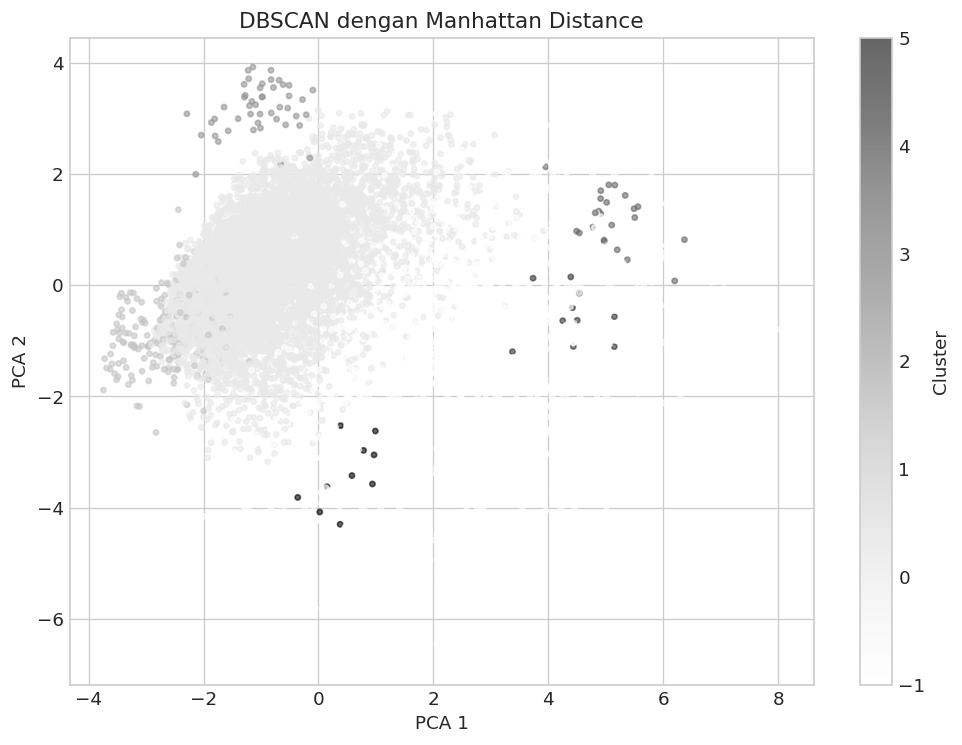

In [48]:
# Reduksi dimensi menjadi 2D
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    s=10,
    alpha=0.6
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('DBSCAN dengan Manhattan Distance')
plt.colorbar(scatter, label='Cluster')

plt.show()



**DBSCAN + Euclidean**

In [50]:
PATH = "/content/drive/MyDrive/glucosafe/Datasate/diabetes_012_health_indicators_BRFSS2015.csv.zip"  # ganti sesuai lokasi file kamu
df = pd.read_csv(PATH)
print("Shape:", df.shape)
df.head()

Shape: (9577, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Cluster,Diabetes_012
0,-0.872425,-0.863917,0.19877,-1.459978,1.101040,-0.211484,-0.325994,-1.756631,-1.309416,-2.030796,...,-0.311281,-0.493475,-0.437389,-0.489159,-0.451214,-0.903647,-0.658485,-0.034631,0,0.0
1,1.146230,-0.863917,0.19877,2.529546,-0.908232,-0.211484,-0.325994,0.569272,0.763699,0.492418,...,-0.311281,1.378212,1.443622,1.777145,-0.451214,-0.903647,0.649878,-2.069356,-1,0.0
2,-0.872425,1.157518,0.19877,0.074454,-0.908232,-0.211484,-0.325994,0.569272,0.763699,0.492418,...,-0.311281,1.378212,-0.437389,-0.489159,-0.451214,1.106627,0.322787,-0.034631,0,0.0
3,-0.872425,-0.863917,0.19877,-0.078989,-0.908232,-0.211484,-0.325994,0.569272,0.763699,0.492418,...,-0.311281,-0.493475,-0.437389,0.304047,-0.451214,-0.903647,0.322787,0.982732,0,0.0
4,-0.872425,-0.863917,0.19877,-0.846205,1.101040,-0.211484,-0.325994,0.569272,0.763699,0.492418,...,-0.311281,-1.429318,-0.437389,-0.489159,-0.451214,-0.903647,0.322787,0.982732,0,0.0


In [51]:
# Cluster (hasil clustering lama) dan Diabetes_012 (label) tidak dipakai sebagai fitur
fitur = df.drop(columns=["Cluster", "Diabetes_012"]).columns.tolist()
X = df[fitur].values   # data sudah terstandarisasi (z-score)

print("Jumlah fitur:", len(fitur))
print(fitur)

Jumlah fitur: 20
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education']


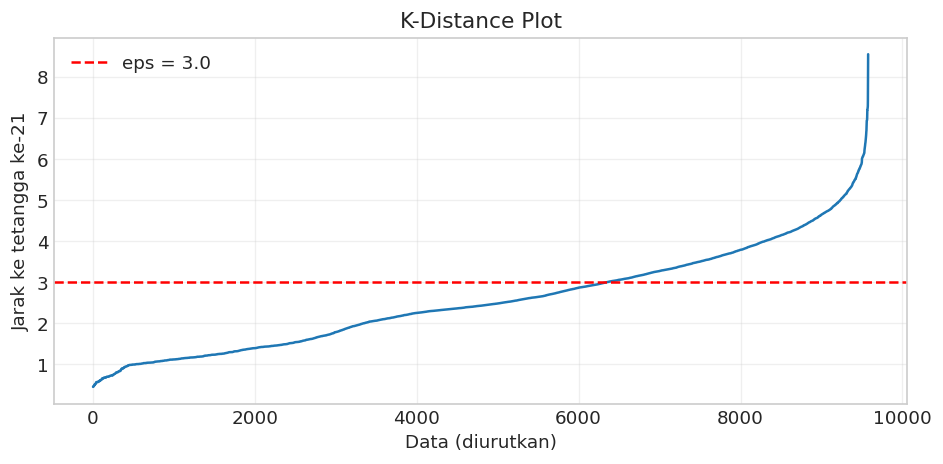

In [52]:
MIN_SAMPLES = 21   # ~ jumlah fitur

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES, metric="euclidean").fit(X)
k_dist = np.sort(nn.kneighbors(X)[0][:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_dist)
plt.axhline(3.0, color="red", ls="--", label="eps = 3.0")
plt.xlabel("Data (diurutkan)")
plt.ylabel(f"Jarak ke tetangga ke-{MIN_SAMPLES}")
plt.title("K-Distance Plot")
plt.legend()
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

In [53]:
hasil = []
for eps in [2.5, 3.0, 3.5, 4.0, 4.5, 5.0]:
    lab = DBSCAN(eps=eps, min_samples=MIN_SAMPLES, metric="euclidean").fit_predict(X)
    n_cl = len(set(lab)) - (1 if -1 in lab else 0)
    mask = lab != -1
    sil = silhouette_score(X[mask], lab[mask]) if n_cl > 1 else np.nan
    hasil.append([eps, n_cl, (lab == -1).sum(), round(sil, 3)])

tabel = pd.DataFrame(hasil, columns=["eps", "n_cluster", "n_noise", "silhouette(non-noise)"])
tabel

,eps,n_cluster,n_noise,silhouette(non-noise)
0,2.5,8,3232,0.179
1,3.0,7,1974,0.200
2,3.5,8,1093,0.186
3,4.0,5,570,0.224
4,4.5,5,227,0.244
5,5.0,2,90,0.258


In [54]:
EPS = 3.0

db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, metric="euclidean")
df["DBSCAN"] = db.fit_predict(X)

n_cluster = len(set(df["DBSCAN"])) - (1 if -1 in df["DBSCAN"].values else 0)
n_noise = (df["DBSCAN"] == -1).sum()

print(f"EPS={EPS}, MIN_SAMPLES={MIN_SAMPLES}")
print("Jumlah cluster :", n_cluster)
print(f"Jumlah noise   : {n_noise} ({n_noise/len(df)*100:.1f}%)")
print()
print(df["DBSCAN"].value_counts().sort_index())

EPS=3.0, MIN_SAMPLES=21
Jumlah cluster : 7
Jumlah noise   : 1974 (20.6%)

DBSCAN
-1    1974
 0    6268
 1     327
 2     217
 3     196
 4     399
 5      53
 6     143
Name: count, dtype: int64


In [55]:
pca = PCA(n_components=2, random_state=42)
pc = pca.fit_transform(X)
df["PC1"], df["PC2"] = pc[:, 0], pc[:, 1]

print("Explained variance PC1+PC2:", pca.explained_variance_ratio_.sum().round(3))

Explained variance PC1+PC2: 0.247


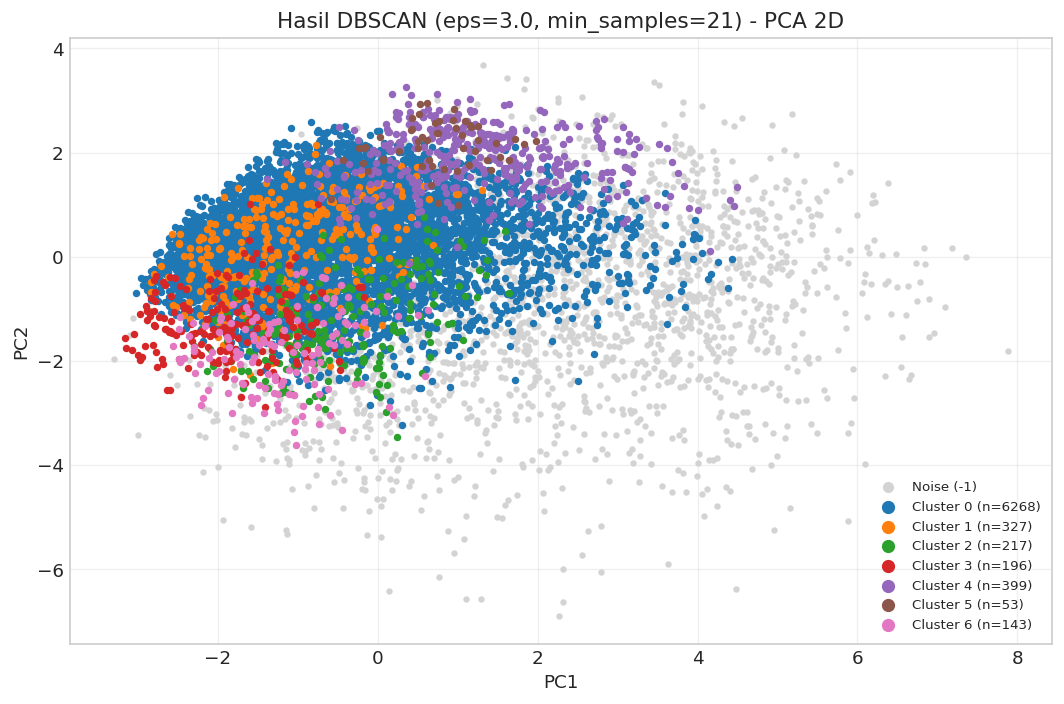

In [56]:
plt.figure(figsize=(9, 6))

noise = df[df["DBSCAN"] == -1]
plt.scatter(noise["PC1"], noise["PC2"], c="lightgrey", s=8, label="Noise (-1)")

for c in sorted(df["DBSCAN"].unique()):
    if c == -1:
        continue
    s = df[df["DBSCAN"] == c]
    plt.scatter(s["PC1"], s["PC2"], s=12, label=f"Cluster {c} (n={len(s)})")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Hasil DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}) - PCA 2D")
plt.legend(markerscale=2, fontsize=8)
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

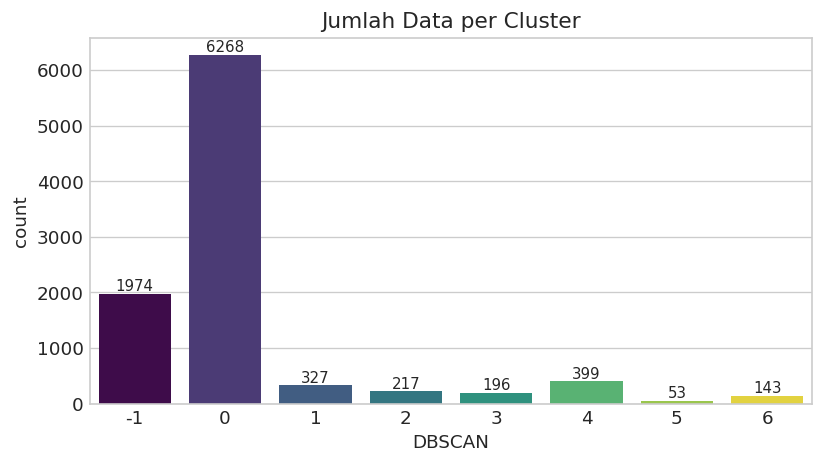

In [57]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(x="DBSCAN", data=df, hue="DBSCAN", palette="viridis", legend=False)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.title("Jumlah Data per Cluster")
plt.tight_layout()
plt.show()

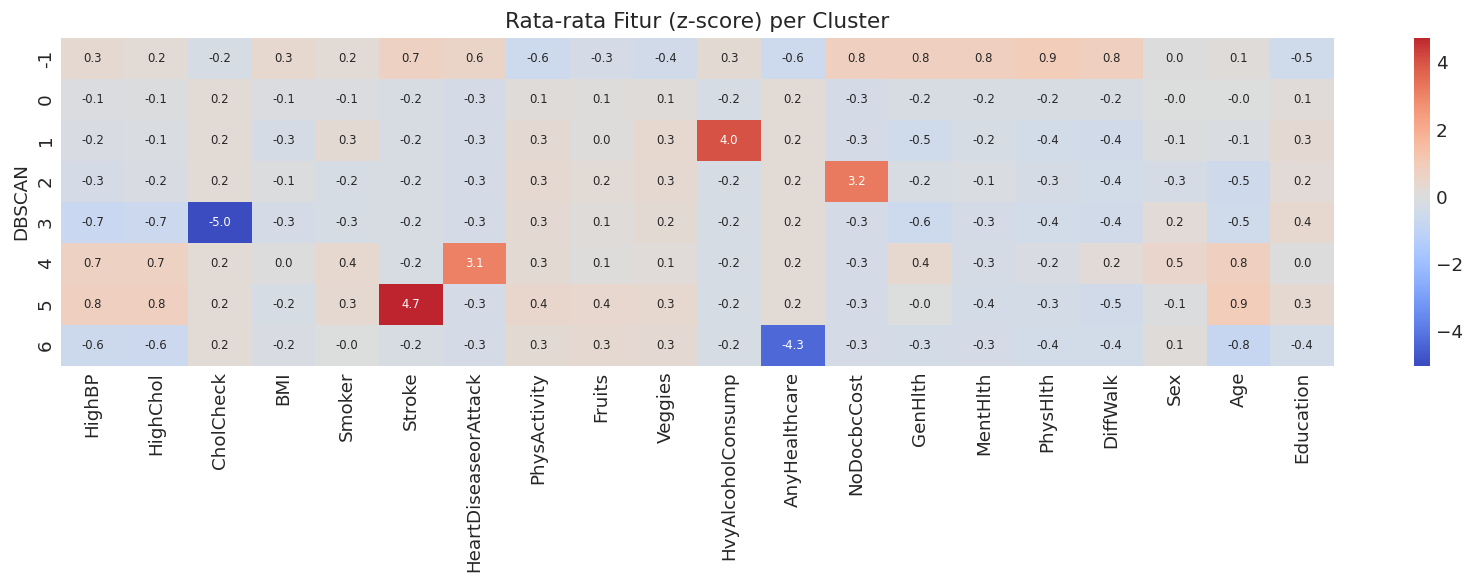

In [58]:
profil = df.groupby("DBSCAN")[fitur].mean()

plt.figure(figsize=(14, 5))
sns.heatmap(profil, cmap="coolwarm", center=0, annot=True, fmt=".1f", annot_kws={"size": 7})
plt.title("Rata-rata Fitur (z-score) per Cluster")
plt.tight_layout()
plt.show()

In [59]:
ct = pd.crosstab(df["DBSCAN"], df["Diabetes_012"].map({0: "Non-diabetes", 1: "Prediabetes", 2: "Diabetes"}))
print("Jumlah:")
display(ct)

ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
print("Persentase per cluster (%):")
display(ct_pct.round(1))

Jumlah:


Diabetes_012,Diabetes,Non-diabetes
DBSCAN,,
-1,487,1487
0,711,5557
1,13,314
2,26,191
3,1,195
4,106,293
5,12,41
6,4,139


Persentase per cluster (%):


Diabetes_012,Diabetes,Non-diabetes
DBSCAN,,
-1,24.7,75.3
0,11.3,88.7
1,4.0,96.0
2,12.0,88.0
3,0.5,99.5
4,26.6,73.4
5,22.6,77.4
6,2.8,97.2


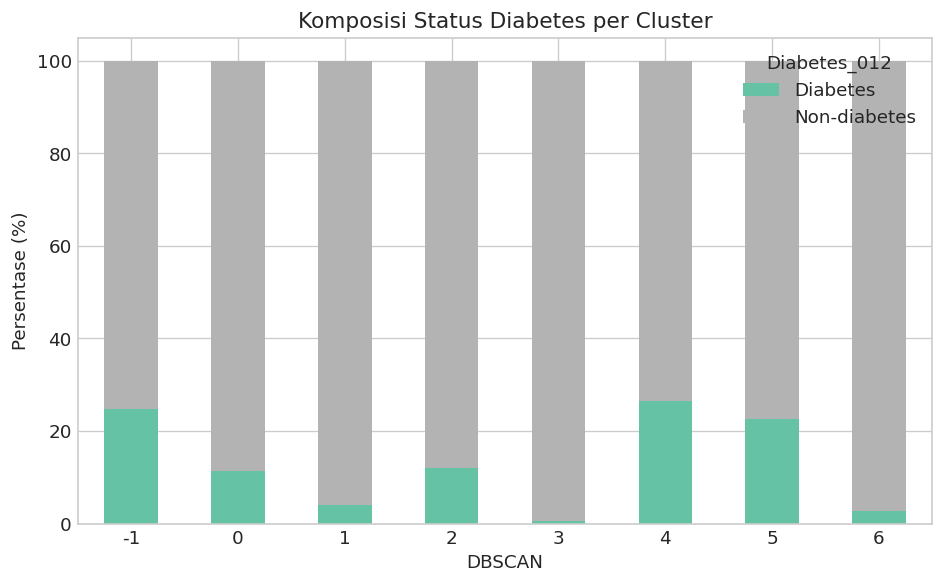

In [60]:
ct_pct.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="Set2")
plt.ylabel("Persentase (%)")
plt.title("Komposisi Status Diabetes per Cluster")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [61]:
mask = df["DBSCAN"] != -1
if n_cluster > 1:
    print("Silhouette Score (tanpa noise):", round(silhouette_score(X[mask], df.loc[mask, "DBSCAN"]), 3))

Silhouette Score (tanpa noise): 0.2


In [62]:
df.drop(columns=["PC1", "PC2"]).to_csv("hasil_dbscan.csv", index=False)
print("Tersimpan: hasil_dbscan.csv")

Tersimpan: hasil_dbscan.csv


**Kmeans Euclidean**

In [63]:
# =======================================================================
# 1. SETUP & IMPORT Library
# =======================================================================
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = "outputKmeans"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("[INFO] Library berhasil diinstall.")
print(f"[INFO] Folder output: '{OUTPUT_DIR}' | Random state: {RANDOM_STATE}")

[INFO] Library berhasil diinstall.
[INFO] Folder output: 'outputKmeans' | Random state: 42


In [64]:
# =======================================================================
# 2. UPLOAD + DATASET (sudah preprocessing sebelumnya)
# =======================================================================
import glob, zipfile
from google.colab import files

TARGET_COL = "Diabetes_012"
OLD_CLUSTER_COL = "Cluster"

# --- Upload (pilih file .zip atau .csv dari laptopmu) ---
if not glob.glob("**/diabetes_012_health_indicators_BRFSS2015*.csv", recursive=True):
    uploaded = files.upload()
    os.makedirs("dataset", exist_ok=True)
    for name in uploaded.keys():
        if name.lower().endswith(".zip"):
            with zipfile.ZipFile(name) as z:
                z.extractall("dataset")
        elif name.lower().endswith(".csv"):
            os.replace(name, os.path.join("dataset", name))

# --- Cari & baca CSV ---
found = glob.glob("**/diabetes_012_health_indicators_BRFSS2015*.csv", recursive=True)
if not found:
    raise FileNotFoundError("CSV tidak ditemukan. Upload zip/csv dulu.")
csv_path = found[0]
print(f"[DATA] Membaca dataset dari: '{csv_path}'")

df_raw = pd.read_csv(csv_path)
print(f"[DATA] Dimensi dataset: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")

# --- Ambil fitur saja (buang label & hasil klaster lama) ---
df_features = df_raw.drop(columns=[TARGET_COL, OLD_CLUSTER_COL]).astype(float)

# --- Data sudah z-score, scaling ulang aman & menjaga hasil konsisten ---
X_scaled = StandardScaler().fit_transform(df_features.values)

print(f"[DATA] Fitur siap dimodelkan ({X_scaled.shape[1]} dimensi): {list(df_features.columns)}")
df_features.head()

[DATA] Membaca dataset dari: 'dataset/diabetes_012_health_indicators_BRFSS2015.csv'
[DATA] Dimensi dataset: 10000 baris x 23 kolom
[DATA] Fitur siap dimodelkan (21 dimensi): ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,-0.866785,-0.858182,0.196922,-1.117071,-0.892119,-0.205637,-0.322458,-1.762814,0.759375,0.482087,...,0.226863,-0.303173,0.457294,-0.024926,0.316350,-0.449718,-0.887021,-0.337933,-1.065595,-1.957312
1,1.153688,1.165254,0.196922,-0.057858,-0.892119,-0.205637,-0.322458,0.567275,0.759375,0.482087,...,0.226863,-0.303173,0.457294,-0.429630,-0.486592,-0.449718,-0.887021,1.626566,0.963272,-0.026012
2,-0.866785,-0.858182,0.196922,-0.663122,-0.892119,-0.205637,-0.322458,0.567275,0.759375,0.482087,...,0.226863,-0.303173,-1.414532,-0.429630,-0.486592,-0.449718,1.127369,-2.302431,-1.065595,0.456813
3,-0.866785,-0.858182,0.196922,-0.209174,1.120927,-0.205637,-0.322458,0.567275,-1.316872,0.482087,...,0.226863,-0.303173,-0.478619,-0.024926,-0.486592,-0.449718,1.127369,-1.975015,-1.065595,0.456813
4,-0.866785,1.165254,0.196922,0.396091,1.120927,-0.205637,-0.322458,-1.762814,0.759375,0.482087,...,0.226863,3.298445,1.393207,3.212703,2.610472,2.223615,-0.887021,-0.010516,-2.080028,-1.957312


Elbow Method & Penentuan K Optimal

[ELBOW] Jumlah Klaster Optimal Terdeteksi: k = 4
[SIMPAN] Grafik Elbow disimpan ke: 'outputKmeans/elbow_euclidean.png'


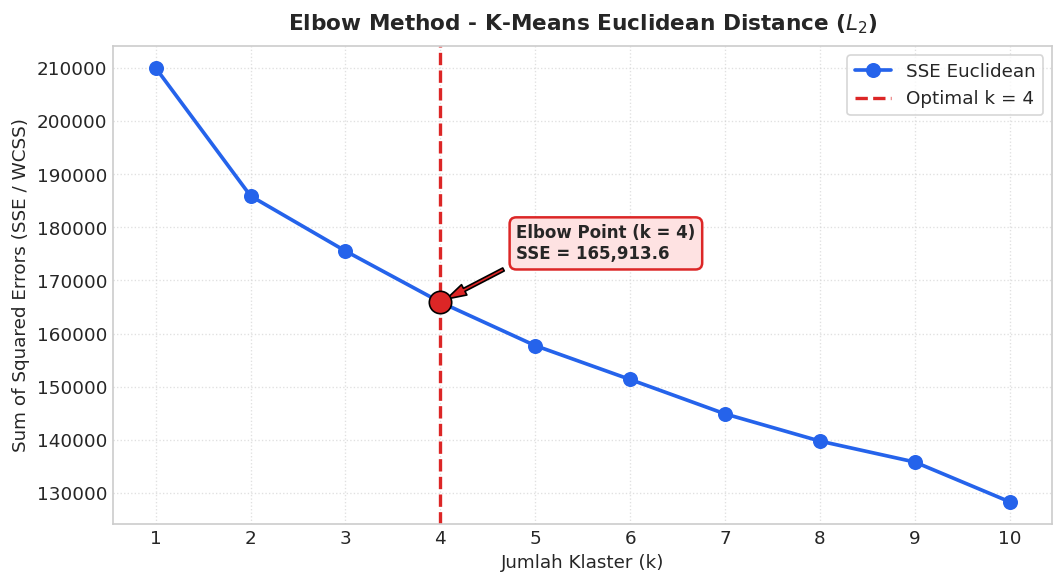

In [65]:

from sklearn.cluster import KMeans

k_range = list(range(1, 11))
sse_euclidean = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    km.fit(X_scaled)
    sse_euclidean.append(km.inertia_)

# Deteksi siku geometris
def find_elbow_point(k_vals, sses):
    p1 = np.array([k_vals[0], sses[0]])
    p2 = np.array([k_vals[-1], sses[-1]])
    line_vec = p2 - p1
    line_unit = line_vec / np.linalg.norm(line_vec)
    dists = [np.linalg.norm((np.array([k, s]) - p1) - np.dot(np.array([k, s]) - p1, line_unit) * line_unit) for k, s in zip(k_vals, sses)]
    return k_vals[np.argmax(dists)]

optimal_k = find_elbow_point(k_range, sse_euclidean)
print(f"[ELBOW] Jumlah Klaster Optimal Terdeteksi: k = {optimal_k}")

# Plotting Elbow Curve
plt.figure(figsize=(9, 5))
plt.plot(k_range, sse_euclidean, marker='o', markersize=8, linewidth=2.2, color='#2563EB', label='SSE Euclidean')
plt.axvline(x=optimal_k, color='#DC2626', linestyle='--', linewidth=2, label=f'Optimal k = {optimal_k}')
plt.scatter([optimal_k], [sse_euclidean[optimal_k - 1]], color='#DC2626', s=180, zorder=5, edgecolor='black')

plt.title('Elbow Method - K-Means Euclidean Distance ($L_2$)', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Jumlah Klaster (k)', fontsize=11)
plt.ylabel('Sum of Squared Errors (SSE / WCSS)', fontsize=11)
plt.xticks(k_range)
plt.annotate(
    f'Elbow Point (k = {optimal_k})\nSSE = {sse_euclidean[optimal_k - 1]:,.1f}',
    xy=(optimal_k, sse_euclidean[optimal_k - 1]),
    xytext=(optimal_k + 0.8, sse_euclidean[optimal_k - 1] + (max(sse_euclidean)-min(sse_euclidean))*0.1),
    arrowprops=dict(facecolor='#DC2626', shrink=0.08, width=2, headwidth=7),
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#FEE2E2", edgecolor="#DC2626", lw=1.5),
    fontweight='bold', fontsize=10
)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

# Simpan grafik
elbow_path = os.path.join(OUTPUT_DIR, "elbow_euclidean.png")
plt.savefig(elbow_path, dpi=300)
print(f"[SIMPAN] Grafik Elbow disimpan ke: '{elbow_path}'")
plt.show()

Kelas K-Means Euclidean

In [66]:

class KMeansEuclidean:
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0
        self.n_iter_ = 0
        self.execution_time_ = 0.0

    def _compute_distance(self, X, centroids):
        # Euclidean distance matrix: ||X - centroids||_2
        return pairwise_distances(X, centroids, metric='euclidean')

    def _init_centroids(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples, _ = X.shape
        first_idx = rng.randint(n_samples)
        centroids = [X[first_idx]]

        for _ in range(1, self.n_clusters):
            cur_c = np.array(centroids)
            dists = self._compute_distance(X, cur_c)
            min_dists = np.min(dists, axis=1)
            sq_dists = min_dists ** 2
            sum_sq = np.sum(sq_dists)
            probs = np.ones(n_samples) / n_samples if sum_sq == 0 else sq_dists / sum_sq
            next_idx = rng.choice(n_samples, p=probs)
            centroids.append(X[next_idx])
        return np.array(centroids)

    def fit(self, X):
        start_time = time.perf_counter()
        self.centroids = self._init_centroids(X)

        for it in range(self.max_iter):
            self.n_iter_ = it + 1
            # Assignment Step: Penugasan sampel ke centroid Euclidean terdekat
            dists = self._compute_distance(X, self.centroids)
            labels = np.argmin(dists, axis=1)

            # Update Step: Pembaruan posisi centroid menggunakan rata-rata aritmetika (mean)
            new_centroids = np.zeros_like(self.centroids)
            rng = np.random.RandomState(self.random_state)
            for k in range(self.n_clusters):
                cluster_pts = X[labels == k]
                if len(cluster_pts) == 0:
                    new_centroids[k] = X[rng.randint(len(X))]
                else:
                    new_centroids[k] = np.mean(cluster_pts, axis=0)

            # Pengecekan konvergensi pergeseran centroid
            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            self.labels_ = labels

            if shift < self.tol:
                break

        # Komputasi Nilai Fungsi Objektif SSE: J = sum_{k=1}^K sum_{x in S_k} ||x - mu_k||_2^2
        final_dists = self._compute_distance(X, self.centroids)
        assigned_dists = final_dists[np.arange(len(X)), self.labels_]
        self.inertia_ = float(np.sum(assigned_dists ** 2))
        self.execution_time_ = float(time.perf_counter() - start_time)
        return self

print("[INFO] Kelas KMeansEuclidean berhasil diinisialisasi.")

[INFO] Kelas KMeansEuclidean berhasil diinisialisasi.


Eksekusi Clustering, Evaluasi, & Ekspor Excel

In [67]:

model_euclidean = KMeansEuclidean(n_clusters=optimal_k, max_iter=300, tol=1e-4, random_state=RANDOM_STATE)
model_euclidean.fit(X_scaled)

# Kalkulasi Metrik Evaluasi Kuantitatif
sil_score = float(silhouette_score(X_scaled, model_euclidean.labels_, metric='euclidean'))
db_score = float(davies_bouldin_score(X_scaled, model_euclidean.labels_))
ch_score = float(calinski_harabasz_score(X_scaled, model_euclidean.labels_))

eval_df = pd.DataFrame([{
    'Distance Metric': 'Euclidean Distance (L2)',
    'Optimal k': optimal_k,
    'Silhouette Score (↑)': round(sil_score, 4),
    'Davies–Bouldin Index (↓)': round(db_score, 4),
    'Calinski–Harabasz Index (↑)': round(ch_score, 2),
    'Execution Time (s) (↓)': round(model_euclidean.execution_time_, 5),
    'Iterations (↓)': model_euclidean.n_iter_,
    'Objective Value (SSE) (↓)': round(model_euclidean.inertia_, 2)
}])

print("\n" + "="*80)
print("TABEL EVALUASI K-MEANS EUCLIDEAN")
print("="*80)
print(eval_df.to_string(index=False))
print("="*80)

# Simpan ke Berkas Excel (.xlsx) dengan 3 Sheet
excel_path = os.path.join(OUTPUT_DIR, "evaluasi_kmeans_euclidean.xlsx")

# Siapkan data hasil klasterisasi
df_clustered = df_raw.copy()
df_clustered['Cluster_Euclidean'] = model_euclidean.labels_

# Profil klaster: rata-rata tiap fitur per klaster + jumlah anggota + sebaran label Diabetes_012
profil_df = df_features.copy()
profil_df['Cluster_Euclidean'] = model_euclidean.labels_
profil_mean = profil_df.groupby('Cluster_Euclidean').mean().round(3)
profil_mean.insert(0, 'Jumlah_Data', profil_df.groupby('Cluster_Euclidean').size())
if TARGET_COL in df_raw.columns:
    diab_dist = pd.crosstab(df_clustered['Cluster_Euclidean'], df_raw[TARGET_COL], normalize='index').round(4) * 100
    diab_dist.columns = [f'%_{TARGET_COL}={c:g}' for c in diab_dist.columns]
    profil_mean = profil_mean.join(diab_dist)

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    df_clustered.to_excel(writer, sheet_name='Data_Terklaster', index=False)
    profil_mean.to_excel(writer, sheet_name='Profil_Klaster')

print(f"[SIMPAN] Hasil evaluasi dan data terklaster disimpan ke: '{excel_path}'")
print("\nProfil klaster (jumlah data & sebaran label Diabetes_012 per klaster):")
profil_mean[['Jumlah_Data'] + [c for c in profil_mean.columns if c.startswith('%_')]]


TABEL EVALUASI K-MEANS EUCLIDEAN
        Distance Metric  Optimal k  Silhouette Score (↑)  Davies–Bouldin Index (↓)  Calinski–Harabasz Index (↑)  Execution Time (s) (↓)  Iterations (↓)  Objective Value (SSE) (↓)
Euclidean Distance (L2)          4                0.0912                     2.562                       885.38                 0.10049              31                  165913.54
[SIMPAN] Hasil evaluasi dan data terklaster disimpan ke: 'outputKmeans/evaluasi_kmeans_euclidean.xlsx'

Profil klaster (jumlah data & sebaran label Diabetes_012 per klaster):


,Jumlah_Data,%_Diabetes_012=0,%_Diabetes_012=1,%_Diabetes_012=2
Cluster_Euclidean,,,,
0,4369,96.45,0.94,2.61
1,1600,65.69,2.94,31.37
2,3548,78.27,2.34,19.39
3,483,86.54,1.86,11.59


Visualisasi PCA 2D

[SIMPAN] Grafik pemetaan klaster disimpan ke: 'outputKmeans/cluster_euclidean.png'


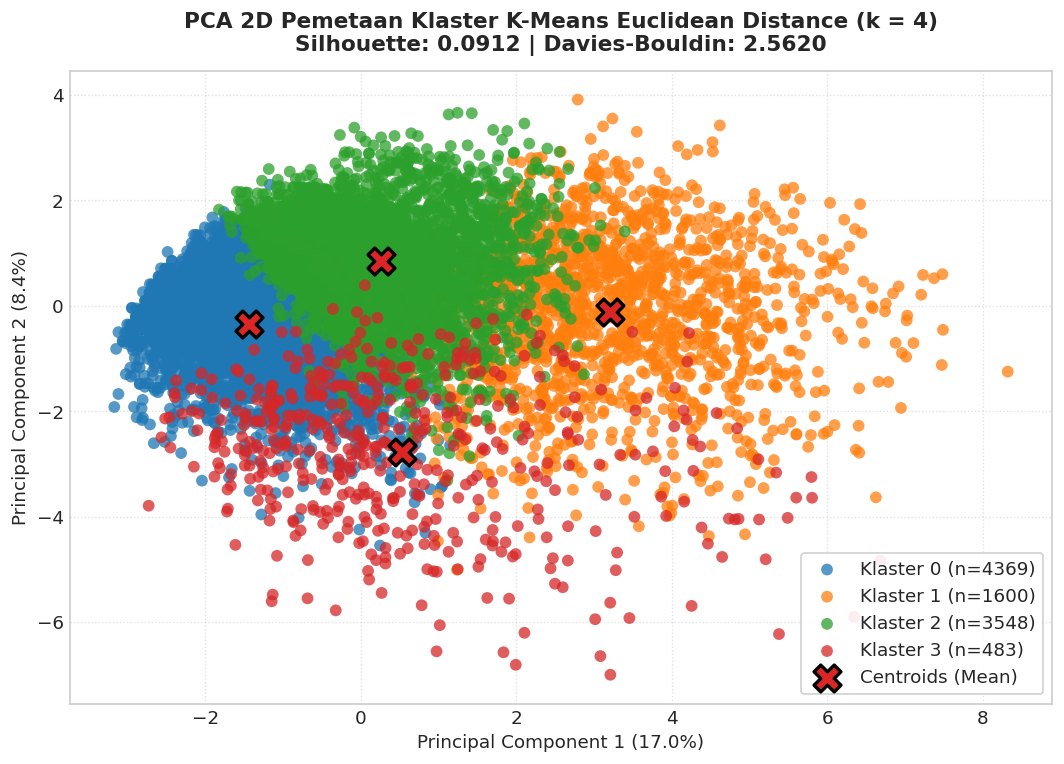

In [68]:

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(model_euclidean.centroids)

plt.figure(figsize=(9, 6.5))
palette = sns.color_palette("tab10", optimal_k)

for k in range(optimal_k):
    mask = (model_euclidean.labels_ == k)
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        color=palette[k],
        label=f'Klaster {k} (n={np.sum(mask)})',
        alpha=0.75,
        s=50,
        edgecolors='none'
    )

plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker='X',
    s=260,
    c='#DC2626',
    edgecolor='black',
    linewidth=2,
    label='Centroids (Mean)',
    zorder=10
)

plt.title(f'PCA 2D Pemetaan Klaster K-Means Euclidean Distance (k = {optimal_k})\n'
          f'Silhouette: {sil_score:.4f} | Davies-Bouldin: {db_score:.4f}',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')
plt.tight_layout()

cluster_path = os.path.join(OUTPUT_DIR, "cluster_euclidean.png")
plt.savefig(cluster_path, dpi=300)
print(f"[SIMPAN] Grafik pemetaan klaster disimpan ke: '{cluster_path}'")
plt.show()

**Kmeans Euclidean**

In [69]:
# =======================================================================
# PEMUATAN DATASET CSV & PIPELINE PRA-PEMROSESAN OTOMATIS
# =======================================================================
import glob, zipfile

TARGET_COL = "Diabetes_012"      # label kelas (tidak dipakai sebagai fitur)
OLD_CLUSTER_COL = "Cluster"      # hasil klasterisasi lama (tidak dipakai sebagai fitur)

def load_and_preprocess_dataset(filepath=None):
    """
    Fungsi untuk membaca dataset CSV, melakukan penanganan missing values,
    pembersihan metadata, seleksi fitur numerik, serta penskalaan (StandardScaler & L2 Normalizer).

    Returns:
        df_raw (pd.DataFrame): Dataframe asli yang dimuat.
        df_features (pd.DataFrame): Dataframe fitur yang siap dimodelkan.
        X_std (np.ndarray): Matriks fitur terstandarisasi (StandardScaler) untuk Euclidean & Manhattan.
        X_norm (np.ndarray): Matriks fitur ternormalisasi L2 (Normalizer) untuk Cosine Similarity.
    """
    # 1. Deteksi Jalur Berkas CSV (upload otomatis di Google Colab jika belum ada)
    if not glob.glob("**/diabetes_012_health_indicators_BRFSS2015*.csv", recursive=True):
        try:
            from google.colab import files
            uploaded = files.upload()   # pilih file .zip atau .csv
            os.makedirs("dataset", exist_ok=True)
            for name in uploaded.keys():
                if name.lower().endswith(".zip"):
                    with zipfile.ZipFile(name) as z:
                        z.extractall("dataset")
                elif name.lower().endswith(".csv"):
                    os.replace(name, os.path.join("dataset", name))
        except ImportError:
            pass

    found = glob.glob("**/diabetes_012_health_indicators_BRFSS2015*.csv", recursive=True)
    if not found:
        raise FileNotFoundError("CSV tidak ditemukan. Upload zip/csv dulu.")
    valid_path = found[0]

    print(f"[DATA] Memuat dataset dari berkas: '{valid_path}'")
    df_raw = pd.read_csv(valid_path)
    print(f"[INFO] Dimensi data mentah: {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom.")

    # 2. Filter Kolom Metadata / Label / Hasil Klaster Lama / Kolom Konstan
    metadata_keywords = ['url', 'source', 'page', 'link', 'redundancy', 'index']
    cols_to_drop = [
        col for col in df_raw.columns
        if any(kw in col.lower() for kw in metadata_keywords)
        or col in (TARGET_COL, OLD_CLUSTER_COL)
        or df_raw[col].nunique() <= 1
    ]
    print(f"[INFO] Kolom dibuang dari fitur: {cols_to_drop}")
    df_clean = df_raw.drop(columns=cols_to_drop)

    # 3. Penanganan Missing Values (Imputasi)
    num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

    if len(num_cols) > 0:
        imputer_num = SimpleImputer(strategy='median')
        df_clean[num_cols] = imputer_num.fit_transform(df_clean[num_cols])

    # 4. Encoding Fitur Kategorikal Berkardinalitas Rendah
    low_card_cats = [c for c in cat_cols if df_clean[c].nunique() <= 10]
    high_card_cats = [c for c in cat_cols if df_clean[c].nunique() > 10]
    df_clean = df_clean.drop(columns=high_card_cats)

    if len(low_card_cats) > 0:
        df_features = pd.get_dummies(df_clean, columns=low_card_cats, drop_first=False, dtype=float)
    else:
        df_features = df_clean.select_dtypes(include=[np.number]).astype(float)

    # 5. Penskalaan Fitur Khusus untuk Metrik Jarak
    X = df_features.values

    # A. StandardScaler: Zero-mean & Unit-variance (Optimal untuk Euclidean & Manhattan)
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X)

    # B. L2 Normalizer: Proyeksi vektor satuan pada hypersphere ||x|| = 1 (Wajib untuk Cosine Similarity)
    normalizer = Normalizer(norm='l2')
    X_norm = normalizer.fit_transform(X_std)

    return df_raw, df_features, X_std, X_norm

# Eksekusi Pemrosesan Data
df_raw, df_features, X_std, X_norm = load_and_preprocess_dataset()

print("\n" + "="*50)
print("PROFIL FITUR SIAP KLUSTER:")
print(f"Jumlah sampel (n) : {X_std.shape[0]}")
print(f"Jumlah dimensi (d): {X_std.shape[1]}")
print(f"Daftar kolom fitur: {list(df_features.columns)}")
print("="*50)
print(df_features.head())

[DATA] Memuat dataset dari berkas: 'dataset/diabetes_012_health_indicators_BRFSS2015.csv'
[INFO] Dimensi data mentah: 10000 baris, 23 kolom.
[INFO] Kolom dibuang dari fitur: ['Cluster', 'Diabetes_012']

PROFIL FITUR SIAP KLUSTER:
Jumlah sampel (n) : 10000
Jumlah dimensi (d): 21
Daftar kolom fitur: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
     HighBP  HighChol  CholCheck       BMI    Smoker    Stroke  \
0 -0.866785 -0.858182   0.196922 -1.117071 -0.892119 -0.205637   
1  1.153688  1.165254   0.196922 -0.057858 -0.892119 -0.205637   
2 -0.866785 -0.858182   0.196922 -0.663122 -0.892119 -0.205637   
3 -0.866785 -0.858182   0.196922 -0.209174  1.120927 -0.205637   
4 -0.866785  1.165254   0.196922  0.396091  1.120927 -0.205637   

   HeartDiseaseorAttack  PhysActivity    Fr

Kelas CustomKMeans Multi-Metrik

In [70]:
# =======================================================================
# IMPLEMENTASI KELAS K-MEANS MULTI-METRIK JARAK (CUSTOM FROM SCRATCH)
# =======================================================================
class CustomKMeans:
    """
    Implementasi K-Means Clustering terpadu yang mendukung 3 fungsi jarak:
    - 'euclidean': Pembaruan centroid menggunakan mean (L2 norm).
    - 'manhattan': Pembaruan centroid menggunakan median per dimensi (L1 norm / K-Medians).
    - 'cosine'   : Pembaruan centroid menggunakan rata-rata ter-normalisasi L2 (Spherical K-Means).
    """
    def __init__(self, n_clusters=3, metric='euclidean', max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.metric = metric.lower()
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        # State atribut model
        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0
        self.n_iter_ = 0
        self.execution_time_ = 0.0

    def _compute_distance(self, X, centroids):
        """Menghitung matriks jarak berpasangan antara sampel X dan centroids."""
        return pairwise_distances(X, centroids, metric=self.metric)

    def _init_centroids(self, X):
        """Inisialisasi centroid cerdas teradaptasi (K-Means++ style)."""
        rng = np.random.RandomState(self.random_state)
        n_samples, _ = X.shape

        # Titik pertama dipilih acak
        first_idx = rng.randint(n_samples)
        centroids = [X[first_idx]]

        # Pilih titik berikutnya proporsional terhadap kuadrat jarak terdekat
        for _ in range(1, self.n_clusters):
            cur_centroids = np.array(centroids)
            dists = self._compute_distance(X, cur_centroids)
            min_dists = np.min(dists, axis=1)
            sq_dists = min_dists ** 2
            sum_sq = np.sum(sq_dists)
            probs = np.ones(n_samples) / n_samples if sum_sq == 0 else sq_dists / sum_sq
            next_idx = rng.choice(n_samples, p=probs)
            centroids.append(X[next_idx])

        centroids = np.array(centroids)
        if self.metric == 'cosine':
            # Proyeksikan centroid awal ke unit hypersphere
            norms = np.linalg.norm(centroids, axis=1, keepdims=True)
            norms[norms == 0] = 1e-10
            centroids = centroids / norms
        return centroids

    def _update_centroids(self, X, labels):
        """Pembaruan posisi centroid sesuai aturan teoritis masing-masing metrik."""
        centroids = np.zeros((self.n_clusters, X.shape[1]))
        rng = np.random.RandomState(self.random_state)

        for k in range(self.n_clusters):
            cluster_pts = X[labels == k]
            if len(cluster_pts) == 0:
                # Penanganan klaster kosong: alokasikan titik acak
                centroids[k] = X[rng.randint(len(X))]
            else:
                if self.metric == 'euclidean':
                    # L2 Norm: Mean aritmetika analitis
                    centroids[k] = np.mean(cluster_pts, axis=0)
                elif self.metric == 'manhattan':
                    # L1 Norm: Median komponen (K-Medians Principle, robust terhadap outlier)
                    centroids[k] = np.median(cluster_pts, axis=0)
                elif self.metric == 'cosine':
                    # Spherical K-Means: Normalisasi vektor rata-rata ke permukaan bola satuan
                    mean_vec = np.mean(cluster_pts, axis=0)
                    norm = np.linalg.norm(mean_vec)
                    centroids[k] = mean_vec / (norm if norm > 0 else 1.0)
        return centroids

    def fit(self, X):
        """Melatih algoritma K-Means hingga konvergen atau mencapai batas iterasi."""
        start_time = time.perf_counter()

        # Pra-kondisi representasi untuk Cosine Similarity
        if self.metric == 'cosine':
            norms = np.linalg.norm(X, axis=1, keepdims=True)
            norms[norms == 0] = 1e-10
            X_calc = X / norms
        else:
            X_calc = X

        # Inisialisasi centroid
        self.centroids = self._init_centroids(X_calc)

        # Loop Optimasi Iteratif (Expectation-Maximization)
        for it in range(self.max_iter):
            self.n_iter_ = it + 1

            # 1. Tahap Penugasan (Assignment Step)
            dists = self._compute_distance(X_calc, self.centroids)
            labels = np.argmin(dists, axis=1)

            # 2. Tahap Pembaruan (Update Step)
            new_centroids = self._update_centroids(X_calc, labels)

            # 3. Pengecekan Kriteria Konvergensi (Tolerance)
            centroid_shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            self.labels_ = labels

            if centroid_shift < self.tol:
                break

        # Komputasi Nilai Fungsi Objektif J = sum_{k=1}^K sum_{x in S_k} d(x, mu_k)^2
        final_dists = self._compute_distance(X_calc, self.centroids)
        assigned_dists = final_dists[np.arange(len(X_calc)), self.labels_]
        self.inertia_ = float(np.sum(assigned_dists ** 2))
        self.execution_time_ = float(time.perf_counter() - start_time)
        return self

    def predict(self, X):
        """Memprediksi klaster sampel baru."""
        if self.metric == 'cosine':
            norms = np.linalg.norm(X, axis=1, keepdims=True)
            norms[norms == 0] = 1e-10
            X_calc = X / norms
        else:
            X_calc = X
        dists = self._compute_distance(X_calc, self.centroids)
        return np.argmin(dists, axis=1)

print("[INFO] Kelas CustomKMeans multi-metrik berhasil didefinisikan.")

[INFO] Kelas CustomKMeans multi-metrik berhasil didefinisikan.


ksekusi 3 Metrik Jarak & Tabel Evaluasi

In [71]:
# =======================================================================
# EKSEKUSI K-MEANS PADA 3 METRIK JARAK & PENYUSUNAN TABEL EVALUASI
# =======================================================================
configurations = {
    'Euclidean': {
        'metric': 'euclidean',
        'data': X_std,
        'eval_metric': 'euclidean',
        'desc': 'L2 Standard Space'
    },
    'Manhattan': {
        'metric': 'manhattan',
        'data': X_std,
        'eval_metric': 'manhattan',
        'desc': 'L1 Robust Median Space'
    },
    'Cosine': {
        'metric': 'cosine',
        'data': X_norm,
        'eval_metric': 'cosine',
        'desc': 'Spherical Unit Hypersphere'
    }
}

trained_models = {}
eval_results = []

for name, cfg in configurations.items():
    print(f"[TRAINING] Melatih K-Means [{name} Distance] dengan k = {optimal_k}...")
    model = CustomKMeans(
        n_clusters=optimal_k,
        metric=cfg['metric'],
        max_iter=300,
        tol=1e-4,
        random_state=RANDOM_STATE
    ).fit(cfg['data'])

    trained_models[name] = model

    # Hitung Metrik Evaluasi Klasterisasi
    sil_score = silhouette_score(cfg['data'], model.labels_, metric=cfg['eval_metric'])
    db_score = davies_bouldin_score(cfg['data'], model.labels_)
    ch_score = calinski_harabasz_score(cfg['data'], model.labels_)

    eval_results.append({
        'Distance Metric': name,
        'Silhouette Score (↑)': sil_score,
        'Davies–Bouldin Index (↓)': db_score,
        'Calinski–Harabasz Index (↑)': ch_score,
        'Execution Time (s) (↓)': model.execution_time_,
        'Iterations (↓)': model.n_iter_,
        'Objective Value (J)': model.inertia_
    })

# Buat DataFrame Perbandingan
df_comparison = pd.DataFrame(eval_results)

# Cetak ringkasan tabel
print("\n" + "="*85)
print("TABEL PERBANDINGAN KOMPREHENSIF METRIK EVALUASI K-MEANS")
print("="*85)
print(df_comparison.to_string(index=False))
print("="*85)

# Simpan ke CSV di direktori artefak
df_comparison.to_csv(os.path.join(OUTPUT_DIR, "metrics_comparison_summary.csv"), index=False)

[TRAINING] Melatih K-Means [Euclidean Distance] dengan k = 4...
[TRAINING] Melatih K-Means [Manhattan Distance] dengan k = 4...
[TRAINING] Melatih K-Means [Cosine Distance] dengan k = 4...

TABEL PERBANDINGAN KOMPREHENSIF METRIK EVALUASI K-MEANS
Distance Metric  Silhouette Score (↑)  Davies–Bouldin Index (↓)  Calinski–Harabasz Index (↑)  Execution Time (s) (↓)  Iterations (↓)  Objective Value (J)
      Euclidean              0.091157                  2.561985                   885.377252                0.109894              31         1.659135e+05
      Manhattan              0.124470                  3.167344                   631.874913                0.021258               4         1.131707e+06
         Cosine              0.158821                  2.830582                   824.538275                0.058014              16         3.395444e+03


Visualisasi PCA 2D

[SAVE] Visualisasi PCA 2D disimpan di: 'outputKmeans/cluster_comparison_pca2d.png'


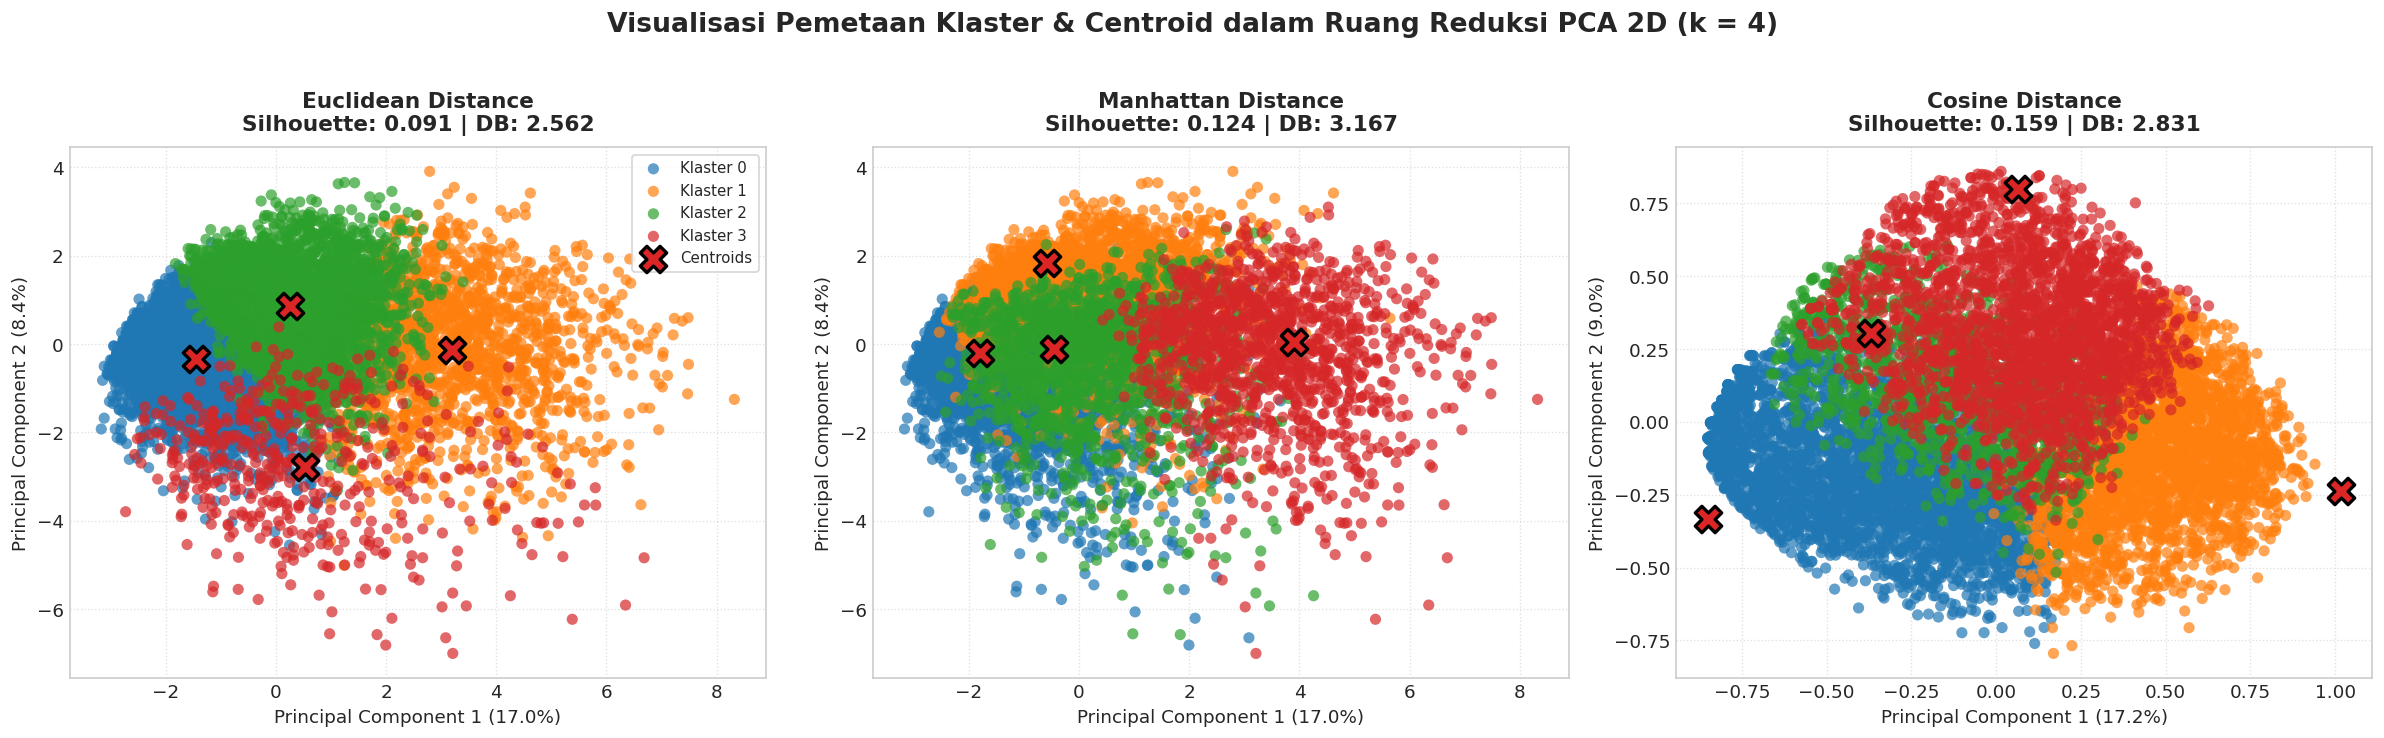

In [72]:
# =======================================================================
# VISUALISASI HASIL KLASTERISASI DENGAN REDUKSI DIMENSI PCA 2D
# =======================================================================
# Proyeksi PCA 2D
pca_std = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_std = pca_std.fit_transform(X_std)

pca_norm = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_norm = pca_norm.fit_transform(X_norm)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
palette = sns.color_palette("tab10", optimal_k)

plots_data = [
    ('Euclidean', trained_models['Euclidean'], X_pca_std, pca_std, 'PCA Euclidean ($L_2$)'),
    ('Manhattan', trained_models['Manhattan'], X_pca_std, pca_std, 'PCA Manhattan ($L_1$)'),
    ('Cosine', trained_models['Cosine'], X_pca_norm, pca_norm, 'PCA Cosine (Spherical)')
]

for idx, (name, model, X_2d, pca_obj, title_suffix) in enumerate(plots_data):
    ax = axes[idx]

    # 1. Plot Titik Data Sesuai Label Klaster
    for k in range(optimal_k):
        mask = (model.labels_ == k)
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            color=palette[k],
            label=f'Klaster {k}',
            alpha=0.7,
            s=45,
            edgecolors='none'
        )

    # 2. Transformasi & Plot Centroid ke Ruang PCA 2D
    centroids_2d = pca_obj.transform(model.centroids)
    ax.scatter(
        centroids_2d[:, 0], centroids_2d[:, 1],
        marker='X',
        s=250,
        c='#DC2626',
        edgecolor='black',
        linewidth=2,
        label='Centroids',
        zorder=10
    )

    # Anotasi info metrik pada judul
    row_info = df_comparison[df_comparison['Distance Metric'] == name].iloc[0]
    ax.set_title(
        f"{name} Distance\nSilhouette: {row_info['Silhouette Score (↑)']:.3f} | DB: {row_info['Davies–Bouldin Index (↓)']:.3f}",
        fontsize=13, fontweight='bold', pad=10
    )
    ax.set_xlabel(f'Principal Component 1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'Principal Component 2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)')
    ax.grid(True, linestyle=':', alpha=0.6)
    if idx == 0:
        ax.legend(frameon=True, loc='best', fontsize=9)

plt.suptitle(f'Visualisasi Pemetaan Klaster & Centroid dalam Ruang Reduksi PCA 2D (k = {optimal_k})', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Simpan Visualisasi
pca_path = os.path.join(OUTPUT_DIR, "cluster_comparison_pca2d.png")
plt.savefig(pca_path, dpi=300, bbox_inches='tight')
print(f"[SAVE] Visualisasi PCA 2D disimpan di: '{pca_path}'")
plt.show()

Bar Chart Perbandingan Metrik

[SAVE] Visualisasi Bar Chart disimpan di: 'outputKmeans/metrics_comparison_barchart.png'


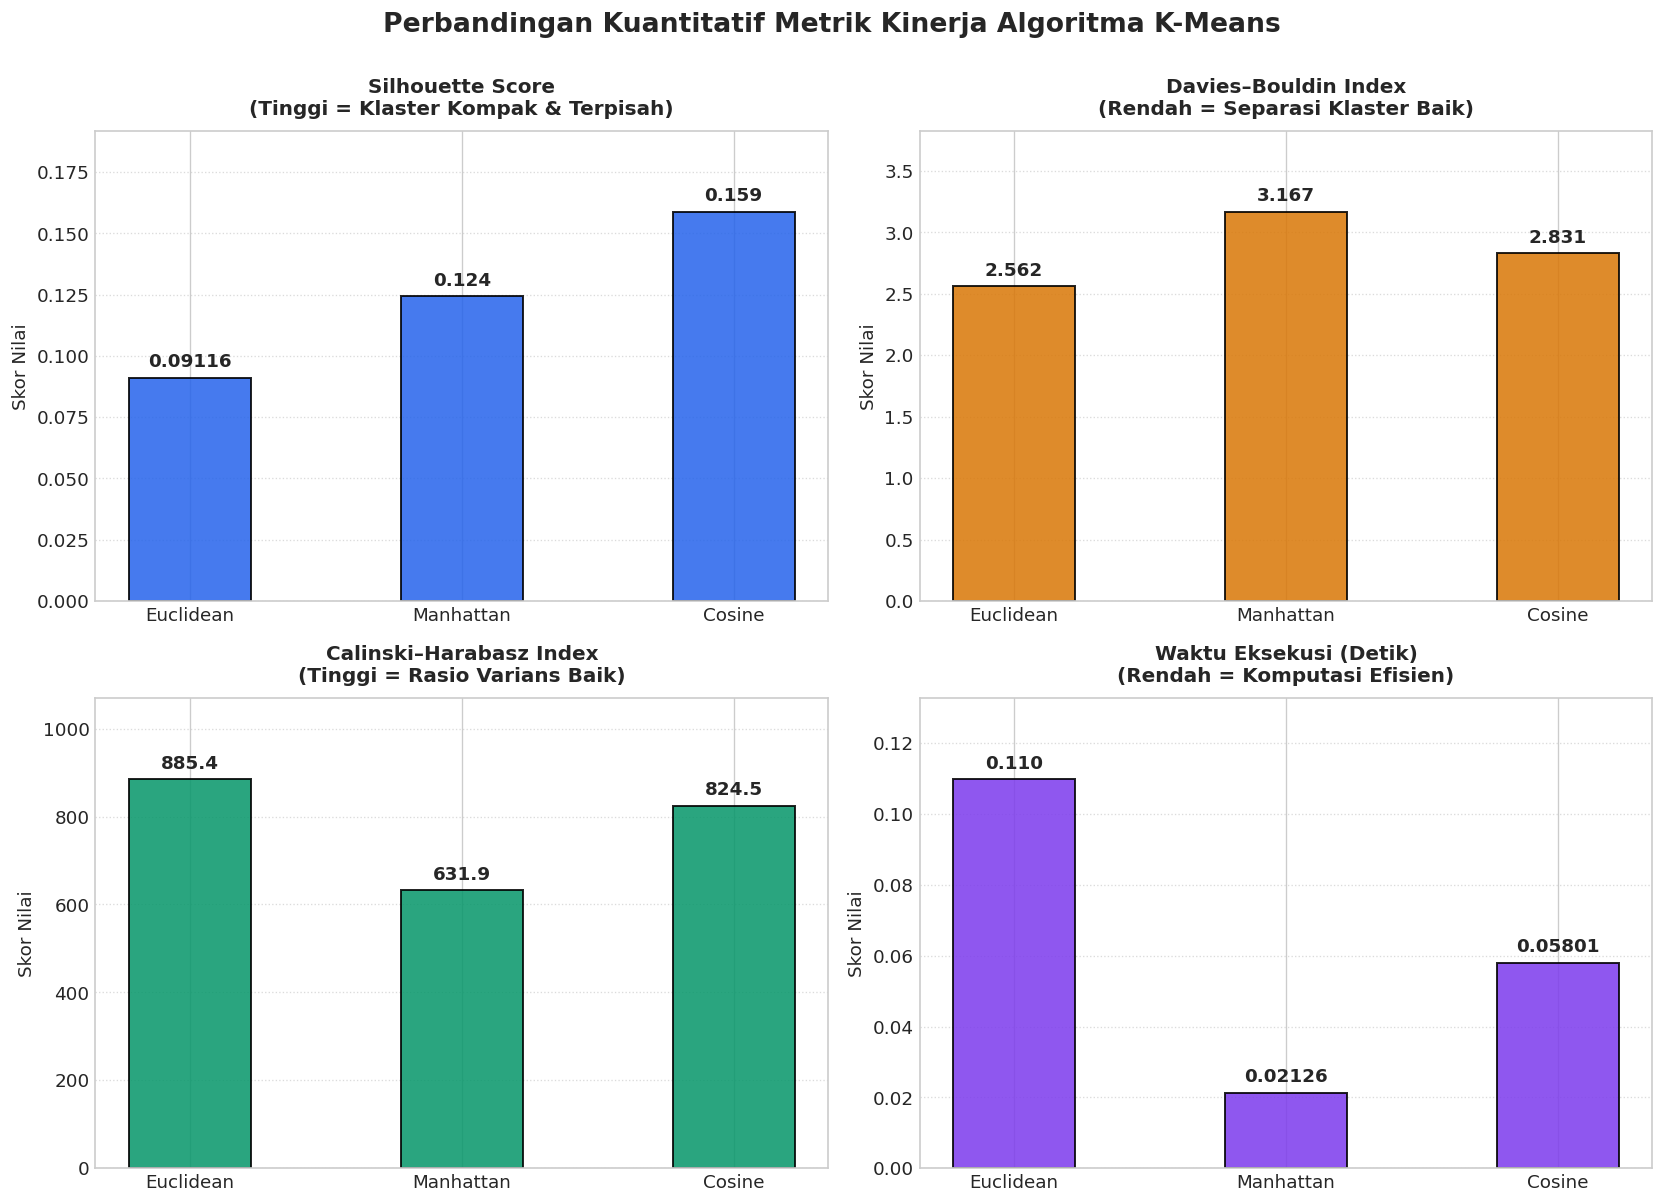

In [73]:
# =======================================================================
# VISUALISASI GRAFIK BATANG (BAR CHART) PERBANDINGAN METRIK EVALUASI
# =======================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_meta = [
    ('Silhouette Score (↑)', 'Silhouette Score\n(Tinggi = Klaster Kompak & Terpisah)', '#2563EB', axes[0, 0]),
    ('Davies–Bouldin Index (↓)', 'Davies–Bouldin Index\n(Rendah = Separasi Klaster Baik)', '#D97706', axes[0, 1]),
    ('Calinski–Harabasz Index (↑)', 'Calinski–Harabasz Index\n(Tinggi = Rasio Varians Baik)', '#059669', axes[1, 0]),
    ('Execution Time (s) (↓)', 'Waktu Eksekusi (Detik)\n(Rendah = Komputasi Efisien)', '#7C3AED', axes[1, 1])
]

metrics_list = df_comparison['Distance Metric'].tolist()

for col_name, title, color, ax in metrics_meta:
    values = df_comparison[col_name].tolist()
    bars = ax.bar(metrics_list, values, color=color, width=0.45, edgecolor='black', linewidth=1.2, alpha=0.85)

    # Berikan Label Angka di Atas Setiap Batang
    for bar in bars:
        h = bar.get_height()
        if abs(h) < 0.1:
            lbl = f"{h:.5f}"
        elif abs(h) < 10:
            lbl = f"{h:.3f}"
        else:
            lbl = f"{h:,.1f}"
        ax.annotate(lbl,
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Skor Nilai')
    ax.grid(axis='y', linestyle=':', alpha=0.7)

    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max * 1.15)

plt.suptitle('Perbandingan Kuantitatif Metrik Kinerja Algoritma K-Means', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()

# Simpan Grafik Batang
barchart_path = os.path.join(OUTPUT_DIR, "metrics_comparison_barchart.png")
plt.savefig(barchart_path, dpi=300, bbox_inches='tight')
print(f"[SAVE] Visualisasi Bar Chart disimpan di: '{barchart_path}'")
plt.show()

**DBSCAN-Manhattan**

In [74]:
df = df_raw.copy()   # <- tambahkan baris ini

print("Tipe data tiap kolom:")
print(df.dtypes.value_counts())

print("\nTotal missing value per kolom (hanya yang > 0):")
mv = df.isnull().sum()
print(mv[mv > 0])

Tipe data tiap kolom:
float64    22
int64       1
Name: count, dtype: int64

Total missing value per kolom (hanya yang > 0):
Series([], dtype: int64)


In [75]:
# Cek data awal
print("Tipe data tiap kolom:")
print(df.dtypes.value_counts())

print("\nTotal missing value per kolom (hanya yang > 0):")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing value")

print(f"\nJumlah baris duplikat: {df.duplicated().sum()}")

print("\nSebaran kelas Diabetes_012 (0=tidak, 1=pra-diabetes, 2=diabetes):")
print(df['Diabetes_012'].value_counts().sort_index())

Tipe data tiap kolom:
float64    22
int64       1
Name: count, dtype: int64

Total missing value per kolom (hanya yang > 0):
Tidak ada missing value

Jumlah baris duplikat: 143

Sebaran kelas Diabetes_012 (0=tidak, 1=pra-diabetes, 2=diabetes):
Diabetes_012
0.0    8460
1.0     180
2.0    1360
Name: count, dtype: int64


In [76]:
# Preprocessing
df_raw = df.copy()
df = df_raw.copy()
n_awal = len(df)

# Buang kelas 1 (pra-diabetes), fokus ke diabetes vs tidak
df = df[df['Diabetes_012'] != 1]
print(f"Setelah buang kelas 1      : {len(df)} baris (terbuang {n_awal - len(df)})")  # laporan jumlah baris setelah kelas 1 dibuang

# Membuang kolom income
df = df.drop(columns=['Income'])
print(f"Setelah buang kolom Income : {df.shape[1]} kolom")

# Menghapus baris duplikat
n_sebelum_dup = len(df)
df = df.drop_duplicates()
print(f"Setelah hapus duplikat     : {len(df)} baris (terbuang {n_sebelum_dup - len(df)})")

# Rapikan nomor baris jadi 0,1,2,... lagi
df = df.reset_index(drop=True)

# Pisahkan tabel fitur dan label
y_label = df['Diabetes_012'].copy()
df_features = df.drop(columns=['Diabetes_012']).astype(float)
print(f"Jumlah fitur untuk klastering: {df_features.shape[1]}")
print(f"Daftar fitur: {list(df_features.columns)}")

# Standardisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values)
print(f"Bentuk data siap klaster: {X_scaled.shape}")
print(f"Cek mean 0 dan std 1: {X_scaled.mean():.4f} / {X_scaled.std():.4f}")
df_features.head()

Setelah buang kelas 1      : 9820 baris (terbuang 180)
Setelah buang kolom Income : 22 kolom
Setelah hapus duplikat     : 9577 baris (terbuang 243)
Jumlah fitur untuk klastering: 21
Daftar fitur: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Cluster']
Bentuk data siap klaster: (9577, 21)
Cek mean 0 dan std 1: 0.0000 / 1.0000


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Cluster
0,-0.866785,-0.858182,0.196922,-1.117071,-0.892119,-0.205637,-0.322458,-1.762814,0.759375,0.482087,...,0.226863,-0.303173,0.457294,-0.024926,0.316350,-0.449718,-0.887021,-0.337933,-1.065595,0.0
1,1.153688,1.165254,0.196922,-0.057858,-0.892119,-0.205637,-0.322458,0.567275,0.759375,0.482087,...,0.226863,-0.303173,0.457294,-0.429630,-0.486592,-0.449718,-0.887021,1.626566,0.963272,0.0
2,-0.866785,-0.858182,0.196922,-0.663122,-0.892119,-0.205637,-0.322458,0.567275,0.759375,0.482087,...,0.226863,-0.303173,-1.414532,-0.429630,-0.486592,-0.449718,1.127369,-2.302431,-1.065595,0.0
3,-0.866785,-0.858182,0.196922,-0.209174,1.120927,-0.205637,-0.322458,0.567275,-1.316872,0.482087,...,0.226863,-0.303173,-0.478619,-0.024926,-0.486592,-0.449718,1.127369,-1.975015,-1.065595,0.0
4,-0.866785,1.165254,0.196922,0.396091,1.120927,-0.205637,-0.322458,-1.762814,0.759375,0.482087,...,0.226863,3.298445,1.393207,3.212703,2.610472,2.223615,-0.887021,-0.010516,-2.080028,-1.0


In [77]:
from sklearn.cluster import DBSCAN

# Mengambil sampel data dari hasil preprocessing
np.random.seed(42)

sample_size = 10000                         # <- definisikan dulu
n_total = X_scaled.shape[0]                 # = 10000
sample_size = min(sample_size, n_total)

sample_idx = np.random.choice(
    n_total,
    size=sample_size,
    replace=False
)

X_sample = X_scaled[sample_idx]
target_sample = y_label.iloc[sample_idx].reset_index(drop=True)

# DBSCAN Manhattan
dbscan = DBSCAN(
    eps=5,
    min_samples=10,
    metric='manhattan',
    n_jobs=-1
)

labels = dbscan.fit_predict(X_sample)

# Ringkasan hasil
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Jumlah klaster : {n_clusters}")
print(f"Jumlah noise   : {np.sum(labels == -1)} ({np.mean(labels == -1)*100:.1f}%)")
print(f"Ukuran klaster : {np.bincount(labels[labels >= 0]).tolist()}")

Jumlah klaster : 6
Jumlah noise   : 2359 (24.6%)
Ukuran klaster : [6945, 183, 47, 23, 10, 10]


In [78]:
# Menambahkan hasil cluster
df_cluster = pd.DataFrame(
    X_sample,
    columns=df_features.columns
)

df_cluster['Cluster'] = labels
df_cluster['Diabetes_012'] = target_sample

df_cluster.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Cluster,Diabetes_012
0,-0.872425,-0.863917,0.19877,-1.459978,1.101040,-0.211484,-0.325994,-1.756631,-1.309416,-2.030796,...,-0.311281,-0.493475,-0.437389,-0.489159,-0.451214,-0.903647,-0.658485,-0.034631,0,0.0
1,1.146230,-0.863917,0.19877,2.529546,-0.908232,-0.211484,-0.325994,0.569272,0.763699,0.492418,...,-0.311281,1.378212,1.443622,1.777145,-0.451214,-0.903647,0.649878,-2.069356,-1,0.0
2,-0.872425,1.157518,0.19877,0.074454,-0.908232,-0.211484,-0.325994,0.569272,0.763699,0.492418,...,-0.311281,1.378212,-0.437389,-0.489159,-0.451214,1.106627,0.322787,-0.034631,0,0.0
3,-0.872425,-0.863917,0.19877,-0.078989,-0.908232,-0.211484,-0.325994,0.569272,0.763699,0.492418,...,-0.311281,-0.493475,-0.437389,0.304047,-0.451214,-0.903647,0.322787,0.982732,0,0.0
4,-0.872425,-0.863917,0.19877,-0.846205,1.101040,-0.211484,-0.325994,0.569272,0.763699,0.492418,...,-0.311281,-1.429318,-0.437389,-0.489159,-0.451214,-0.903647,0.322787,0.982732,0,0.0


In [79]:
# Jumlah data setiap cluster
cluster_counts = df_cluster['Cluster'].value_counts().sort_index()

print(cluster_counts)

# Jumlah cluster tanpa noise
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Jumlah noise
n_noise = list(labels).count(-1)

print("Jumlah Cluster :", n_clusters)
print("Jumlah Noise   :", n_noise)

# Data tanpa noise
mask = labels != -1

X_eval = X_sample[mask]
labels_eval = labels[mask]

# Evaluasi Silhouette Score
if len(set(labels_eval)) > 1:
    silhouette = silhouette_score(
        X_eval,
        labels_eval,
        metric='manhattan'
    )
    print("Silhouette Score (Manhattan):", silhouette)
else:
    print("Silhouette Score tidak dapat dihitung karena cluster kurang dari 2.")

# Evaluasi Davies-Bouldin Index
if len(set(labels_eval)) > 1:
    dbi = davies_bouldin_score(
        X_eval,
        labels_eval
    )
    print("Davies-Bouldin Index:", dbi)
else:
    print("DBI tidak dapat dihitung.")

# Evaluasi Calinski-Harabasz Index
if len(set(labels_eval)) > 1:
    ch = calinski_harabasz_score(
        X_eval,
        labels_eval
    )
    print("Calinski-Harabasz Index:", ch)
else:
    print("CH Index tidak dapat dihitung.")

Cluster
-1    2359
 0    6945
 1     183
 2      47
 3      23
 4      10
 5      10
Name: count, dtype: int64
Jumlah Cluster : 6
Jumlah Noise   : 2359
Silhouette Score (Manhattan): 0.27643439353690846
Davies-Bouldin Index: 0.9338628415253898
Calinski-Harabasz Index: 154.28286297495686


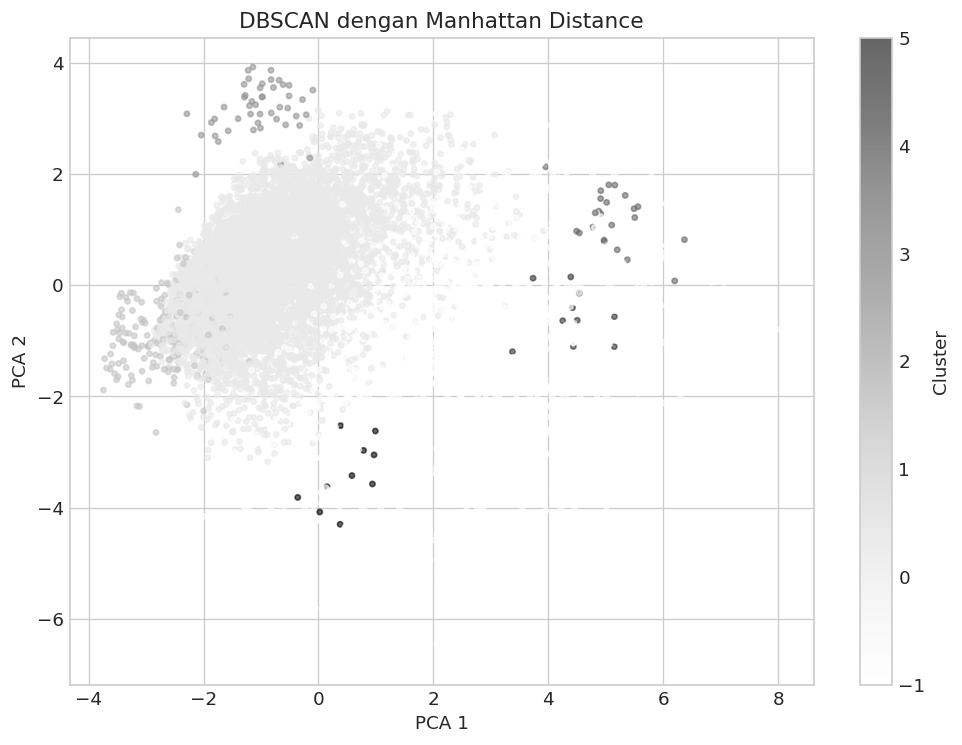

In [80]:
# Reduksi dimensi menjadi 2D
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    s=10,
    alpha=0.6
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('DBSCAN dengan Manhattan Distance')
plt.colorbar(scatter, label='Cluster')

plt.show()

In [81]:
# Simpan hasil clustering
df_cluster.to_csv(
    '/content/drive/MyDrive/glucosafe/Datasate/diabetes_012_health_indicators_BRFSS2015.csv.zip',
    index=False
)

print("Hasil berhasil disimpan.")

Hasil berhasil disimpan.
